## PR2610: Analiza dirk Formule 1
### Projektna naloga pri predmetu Podatkovno Rudarjenje

In [62]:
# pip install fastf1
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [63]:
fastf1.Cache.enable_cache('./cache')
# plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

## Tyre degradation

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data


core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '31', '44', '5', '14', '63', '6', '4', '3', '18', '22', '20', '77', '24', '47', '10', '55', '23']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '63', '55', '44', '11', '4', '10', '45', '24', '31', '47', '77', '22', '6', '20', '3', '18', '14', '5']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.


Skupaj krogov: 3226
Spojine: ['INTERMEDIATE' 'WET' 'HARD' 'MEDIUM' 'SOFT']


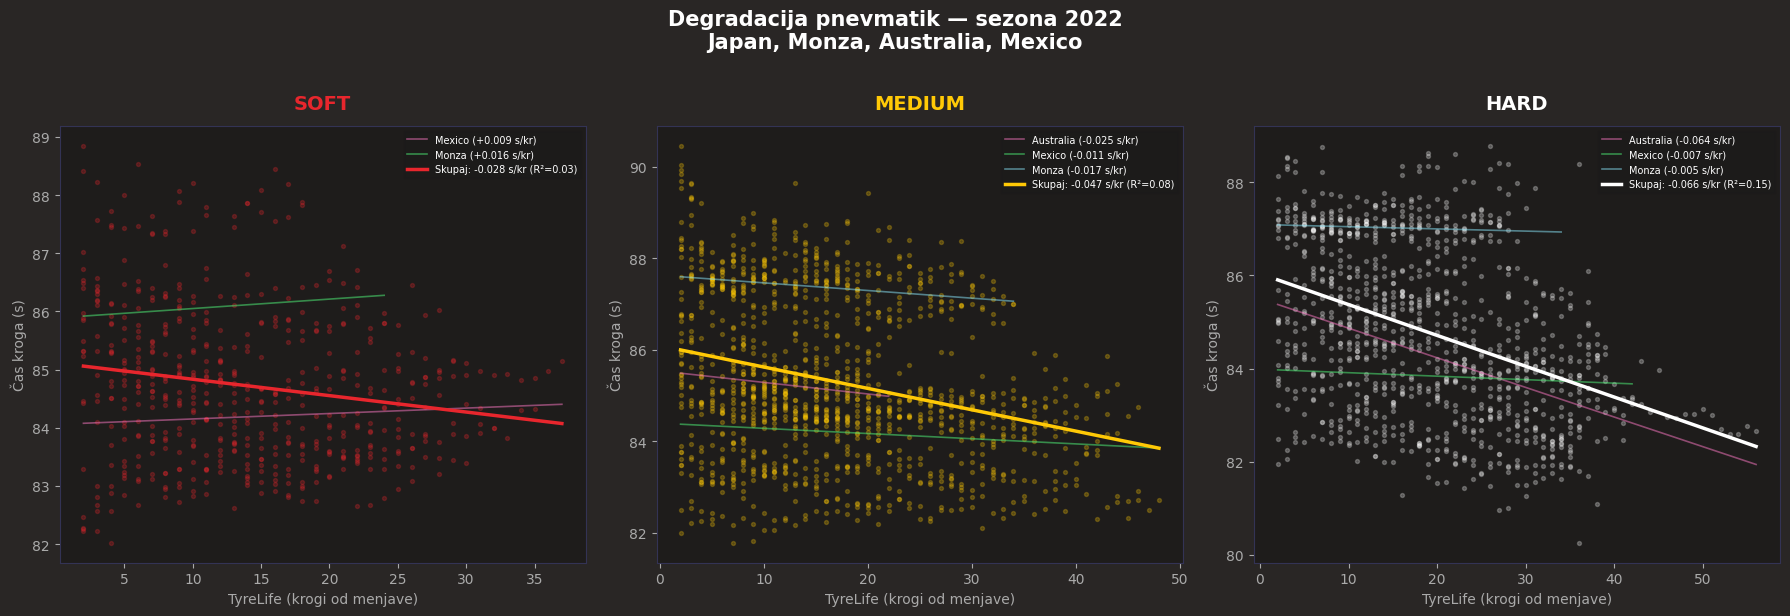

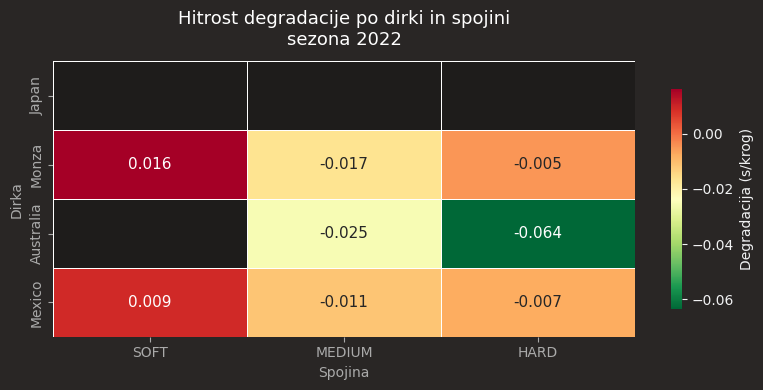

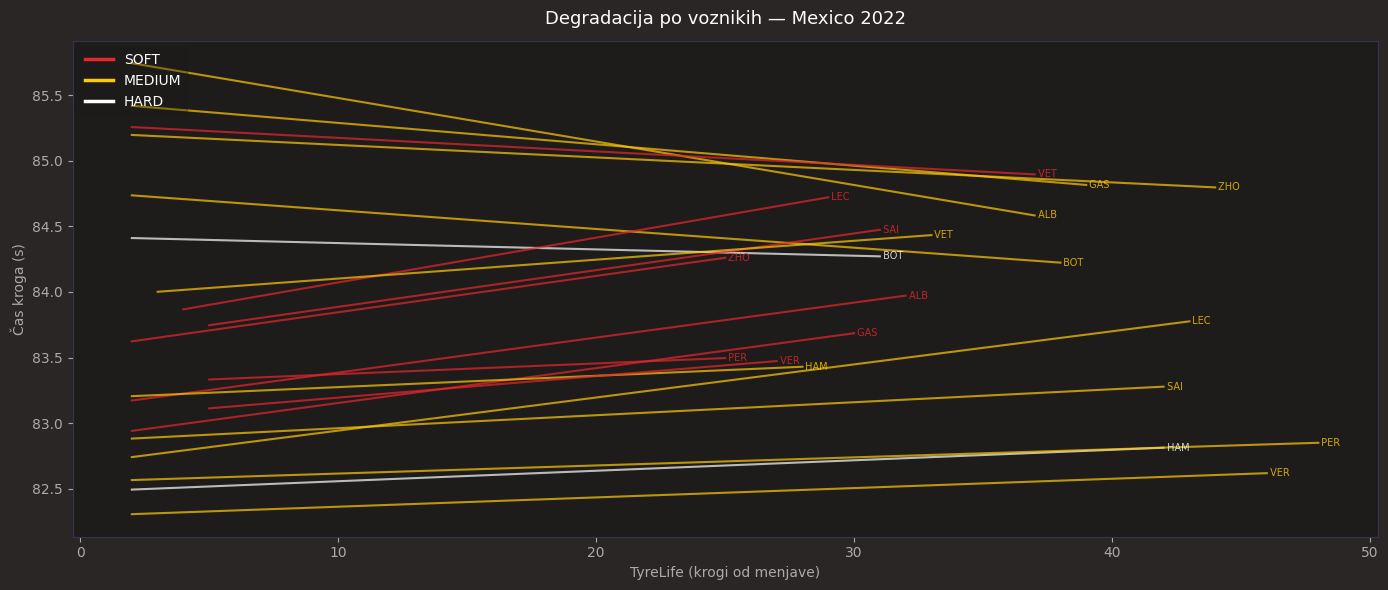


── Povprečna degradacija po spojini (s/krog) ──
            mean     std     min     max
Compound                                
HARD     -0.0253  0.0332 -0.0636 -0.0047
MEDIUM   -0.0178  0.0070 -0.0253 -0.0113
SOFT      0.0128  0.0049  0.0093  0.0162

── Najhitrejša degradacija po dirki ──
     Race Compound  Slope_s_per_lap
Australia   MEDIUM        -0.025264
   Mexico     SOFT         0.009331
    Monza     SOFT         0.016242


In [64]:
# Nastavitve
SEASON = 2022
# Dirke
RACES = ['Japan', 'Monza', 'Australia', 'Mexico']
DRIVERS = None  # None = vsi
COMPOUND_COLORS = {
    'SOFT':   '#E8262D',
    'MEDIUM': '#FFC906',
    'HARD':   '#FFFFFF',
    'INTER':  '#39B54A',
    'WET':    '#0067FF',
}
MIN_LAPS_FOR_FIT = 5    # najmanjše število krogov za regresijsko premico
 
# Funkcije
def load_race_laps(season: int, race_name: str) -> pd.DataFrame:
    """Naloži in filtrira kroge ene dirke"""
    session = fastf1.get_session(season, race_name, 'R')
    session.load(laps=True, weather=False, telemetry=False, messages=False)
 
    laps = session.laps.copy()
 
    # Ohrani samo veljavne, natančne kroge (brez SC, VSC, pit in/out)
    laps = laps.pick_accurate()
    laps = laps[laps['PitOutTime'].isna() & laps['PitInTime'].isna()]
 
    # Pretvori LapTime v sekunde
    laps['LapTime_s'] = laps['LapTime'].dt.total_seconds()
 
    # Odstrani osamelce (> 3σ od mediane za vsako trdoto)
    def remove_outliers(group):
        med = group['LapTime_s'].median()
        sd  = group['LapTime_s'].std()
        return group[np.abs(group['LapTime_s'] - med) < 3 * sd]
 
    laps = laps.groupby('Compound', group_keys=False).apply(remove_outliers)

    laps['Race'] = race_name
    laps['Season'] = season
 
    # Ohrani samo pomebne stolpce
    keep = ['Race', 'Season', 'Driver', 'Team', 'LapNumber',
            'Compound', 'TyreLife', 'LapTime_s', 'Stint']
    return laps[[c for c in keep if c in laps.columns]].dropna(subset=['LapTime_s', 'TyreLife'])
 
 
def degradation_slope(group: pd.DataFrame) -> float:
    """Vrne naklon linearne regresije LapTime ~ TyreLife (s/krog)."""
    if len(group) < MIN_LAPS_FOR_FIT:
        return np.nan
    slope, *_ = stats.linregress(group['TyreLife'], group['LapTime_s'])
    return slope
 
 
# Nalaganje podatkov
all_laps = []
for race in RACES:
    try:
        df = load_race_laps(SEASON, race)
        all_laps.append(df)
    except Exception as e:
        print(f"NAPAKA: {e}")
 
if not all_laps:
    raise RuntimeError("Ni bilo mogoče naložiti nobene dirke.")
 
laps_all = pd.concat(all_laps, ignore_index=True)
 
# Filtriraj voznike
if DRIVERS:
    laps_all = laps_all[laps_all['Driver'].isin(DRIVERS)]
 
print(f"\nSkupaj krogov: {len(laps_all)}")
print(f"Spojine: {laps_all['Compound'].unique()}")
 
# Ohrani samo osnovne (brez INT/WET ko ni dež)
PRIMARY = ['SOFT', 'MEDIUM', 'HARD']
laps_dry = laps_all[laps_all['Compound'].isin(PRIMARY)].copy()
 
# Graf 1: Degradacija po spojini (vse dirke skupaj)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
#fig.patch.set_facecolor('#1a1a2e')
 
for ax, compound in zip(axes, PRIMARY):
    data = laps_dry[laps_dry['Compound'] == compound]
    color = COMPOUND_COLORS[compound]
    text_color = '#1a1a2e' if compound == 'HARD' else color
 
    # Scatter: posamezni krogi
    ax.scatter(data['TyreLife'], data['LapTime_s'],
               alpha=0.25, s=8, color=color, zorder=2)
 
    # Po dirki: barvni trend
    for race, rdf in data.groupby('Race'):
        if len(rdf) < MIN_LAPS_FOR_FIT:
            continue
        x = rdf['TyreLife'].values
        y = rdf['LapTime_s'].values
        m, b, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        ax.plot(xfit, m * xfit + b, alpha=0.5, lw=1.2,
                label=f'{race} ({m:+.3f} s/kr)')
 
    # Skupna regresija
    if len(data) >= MIN_LAPS_FOR_FIT:
        m, b, r, p, _ = stats.linregress(data['TyreLife'], data['LapTime_s'])
        xfit = np.linspace(data['TyreLife'].min(), data['TyreLife'].max(), 100)
        ax.plot(xfit, m * xfit + b, color=color, lw=2.5, zorder=5,
                label=f'Skupaj: {m:+.3f} s/kr (R²={r**2:.2f})')
 
    ax.set_title(compound, color=color, fontsize=14, fontweight='bold')
    ax.set_xlabel('TyreLife (krogi od menjave)', color='#aaaaaa')
    ax.set_ylabel('Čas kroga (s)', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333355')
    ax.legend(fontsize=7, framealpha=0.3, labelcolor='white')
 
fig.suptitle(f'Degradacija pnevmatik — sezona {SEASON}\n{", ".join(RACES)}',
             color='white', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
# Graf 2: Heatmap naklonov degradacije (spojina × dirka)
 
slopes = (
    laps_dry
    .groupby(['Race', 'Compound'])
    .apply(degradation_slope)
    .reset_index(name='Slope_s_per_lap')
)
 
pivot = slopes.pivot(index='Race', columns='Compound', values='Slope_s_per_lap')
pivot = pivot.reindex(columns=[c for c in PRIMARY if c in pivot.columns])
pivot = pivot.reindex(RACES)   # ohrani vrstni red dirk
 
fig, ax = plt.subplots(figsize=(8, max(4, len(RACES) * 0.9)))
 
sns.heatmap(
    pivot,
    annot=True, fmt='.3f', linewidths=0.5,
    cmap='RdYlGn_r',   # rdeča = hitra degradacija, zelena = počasna
    ax=ax,
    cbar_kws={'label': 'Degradacija (s/krog)', 'shrink': 0.8},
    annot_kws={'size': 11}
)
ax.set_title(f'Hitrost degradacije po dirki in spojini\nsezona {SEASON}',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Spojina', color='#aaaaaa')
ax.set_ylabel('Dirka', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
 
plt.tight_layout()
plt.show()
 
# Graf 3: Primerjava med vozniki (izbrana dirka, vse spojine)
 
# Vzami dirko z največ podatki
best_race = laps_dry.groupby('Race').size().idxmax()
race_data = laps_dry[laps_dry['Race'] == best_race]
 
# Top 10 voznikov po številu krogov
top_drivers = race_data.groupby('Driver').size().nlargest(10).index.tolist()
race_data = race_data[race_data['Driver'].isin(top_drivers)]
 
fig, ax = plt.subplots(figsize=(14, 6))
 
for driver, ddf in race_data.groupby('Driver'):
    for compound, cdf in ddf.groupby('Compound'):
        if len(cdf) < MIN_LAPS_FOR_FIT:
            continue
        m, b, r, p, _ = stats.linregress(cdf['TyreLife'], cdf['LapTime_s'])
        xfit = np.linspace(cdf['TyreLife'].min(), cdf['TyreLife'].max(), 50)
        ax.plot(xfit, m * xfit + b,
                color=COMPOUND_COLORS[compound], alpha=0.7, lw=1.5)
        ax.text(xfit[-1], m * xfit[-1] + b, f' {driver}',
                fontsize=7, color=COMPOUND_COLORS[compound], va='center', alpha=0.8)
 
# Legenda za spojine
for comp, col in COMPOUND_COLORS.items():
    if comp in PRIMARY:
        ax.plot([], [], color=col, lw=2.5, label=comp)
ax.legend(loc='upper left', framealpha=0.3, labelcolor='white')
 
ax.set_title(f'Degradacija po voznikih — {best_race} {SEASON}',
             color='white', fontsize=13)
ax.set_xlabel('TyreLife (krogi od menjave)', color='#aaaaaa')
ax.set_ylabel('Čas kroga (s)', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.spines[:].set_color('#333355')
 
plt.tight_layout()
plt.show()
 
# Povzetek
 
print("\n── Povprečna degradacija po spojini (s/krog) ──")
print(slopes.groupby('Compound')['Slope_s_per_lap']
      .agg(['mean', 'std', 'min', 'max'])
      .round(4)
      .to_string())
 
print("\n── Najhitrejša degradacija po dirki ──")
worst = slopes.loc[slopes.groupby('Race')['Slope_s_per_lap'].idxmax()]
print(worst[['Race', 'Compound', 'Slope_s_per_lap']].to_string(index=False))